# Thesis Experiment: SAC-Based Gamma Controller — **Sortino Ratio Reward**
**Setup:** 7-Day Rebalancing Frequency | SAC Algorithm | Multi-seed evaluation

**Perubahan utama dari versi sebelumnya:**
- Reward utama diganti ke **`sortino_ratio`** — hanya menghukum downside volatility (lebih tepat untuk kripto)
- Reward `sharpe_incremental` tetap disertakan sebagai perbandingan internal
- **Phase Final:** Perbandingan Sortino Ratio semua strategi di training & testing

**Mengapa Sortino lebih baik dari Sharpe untuk kripto?**
- Sharpe menghukum volatilitas ke atas (upside) — tidak fair
- Sortino hanya menghukum **downside volatility** (return < 0)
- Distribusi return kripto bersifat *fat-tailed* → Sharpe tidak valid secara statistik

## Setup & Install

In [1]:
%pip install stable_baselines3[extra]

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ================================================================
# GLOBAL EXPERIMENT SETTINGS
# ================================================================
SEEDS        = [42, 123, 77]   # 3 seeds untuk credibility statistik
TRAIN_STEPS  = 1000           # Steps untuk konvergensi SAC
GAMMA_CENTER = 1.0
GAMMA_RANGE  = 1.0
SET_WINDOW   = 30
SET_REBALANCE = 7
SORTINO_WINDOW = 20            # Rolling window untuk Sortino reward
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import SAC
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement

from scipy.optimize import minimize
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded. SAC + Sortino Reward mode active.')
print(f'Settings: Seeds={SEEDS}, Steps={TRAIN_STEPS}, Gamma={GAMMA_CENTER}, SortinoWindow={SORTINO_WINDOW}')

Libraries loaded. SAC + Sortino Reward mode active.
Settings: Seeds=[42, 123, 77], Steps=1000, Gamma=1.0, SortinoWindow=20


## Phase 1: Data Preparation

In [3]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    train_df  = df.iloc[:split_idx]
    test_df   = df.iloc[split_idx:]
    return train_df, test_df, assets

ret_old, ret_test, assets = load_and_split(file_data)

print(f'Assets ({len(assets)}): {assets}')
print(f'Training : {ret_old.index[0].date()} – {ret_old.index[-1].date()} ({len(ret_old)} days)')
print(f'Testing  : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')

USDT removed from assets.
Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training : 2017-09-15 – 2019-03-02 (534 days)
Testing  : 2019-03-03 – 2019-10-17 (229 days)


## Phase 2: Core Functions

In [4]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1/Q))**2
    eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def get_centrality_weights(returns_window, gamma=1.0):
    T, N = returns_window.shape
    mu    = returns_window.mean().values
    sigma = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    fun  = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    bnds = tuple((0, 0.4) for _ in range(N))
    res  = minimize(fun, np.ones(N)/N, method='SLSQP', bounds=bnds, constraints=cons)
    return res.x if res.success else np.ones(N)/N


def get_network_metrics(returns_window):
    T, N = returns_window.shape
    corr_f   = apply_rmt_filter(returns_window)
# 1. Network Density (standard undirected: ignore diagonal)
upper_idx = np.triu_indices(N, k=1)
density   = np.sum(np.abs(corr_f[upper_idx]) > 0.1) / (N * (N - 1) / 2) if N > 1 else 0.0
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full   = nx.from_numpy_array(dist_mat)
    mst      = nx.minimum_spanning_tree(G_full)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec   = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return np.array([
        np.std(cent_vec)  * 10,
        np.mean(cent_vec) * 10,
        mst_dist          * 0.1,
        np.max(cent_vec),
        density
    ], dtype=np.float32)


def calculate_sortino(returns_series, ann_factor=252, mar=0.0):
    """
    Hitung Sortino Ratio dari return series.
    mar = Minimum Acceptable Return (default 0 = risk-free = 0)
    Sortino = (Ann.Return - MAR) / Downside Deviation
    """
    returns_arr = np.array(returns_series)
    ann_ret = (1 + returns_arr).prod() ** (ann_factor / len(returns_arr)) - 1
    downside = returns_arr[returns_arr < mar]
    if len(downside) == 0:
        return np.inf  # tidak ada return negatif → Sortino sempurna
    downside_std = np.sqrt(np.mean(downside**2)) * np.sqrt(ann_factor)
    return (ann_ret - mar) / (downside_std + 1e-8)


def calculate_metrics(returns_series):
    """Metrik performa portfolio lengkap termasuk Sortino Ratio."""
    returns_arr = np.array(returns_series)
    total_ret   = (1 + returns_arr).prod() - 1
    ann_ret     = (1 + total_ret) ** (252 / len(returns_arr)) - 1
    ann_vol     = returns_arr.std() * np.sqrt(252)
    sharpe      = ann_ret / ann_vol if ann_vol > 0 else 0
    sortino     = calculate_sortino(returns_arr)
    cumulative  = (1 + returns_arr).cumprod()
    peak        = np.maximum.accumulate(cumulative)
    drawdown    = (cumulative - peak) / peak
    max_dd      = drawdown.min()
    calmar      = ann_ret / abs(max_dd) if max_dd != 0 else 0
    # Downside deviation
    downside    = returns_arr[returns_arr < 0]
    down_std    = np.std(downside) * np.sqrt(252) if len(downside) > 0 else 0
    return {
        'Total Return'      : total_ret,
        'Ann. Return'       : ann_ret,
        'Ann. Volatility'   : ann_vol,
        'Downside Std'      : down_std,
        'Sharpe Ratio'      : sharpe,
        'Sortino Ratio'     : sortino,   # ← metrik utama
        'Calmar Ratio'      : calmar,
        'Max Drawdown'      : max_dd,
    }


print('Core functions defined (termasuk calculate_sortino).')

Core functions defined (termasuk calculate_sortino).


In [5]:
class PortfolioStrategy:
    def __init__(self, name):
        self.name = name
        self.last_gamma = 1.0
    def compute_weights(self, returns_window): raise NotImplementedError()


class ClassicalMarkowitz(PortfolioStrategy):
    """Benchmark: Minimum Variance (no network regularization)."""
    def compute_weights(self, rw):
        cov = rw.cov().values
        inv_cov = np.linalg.pinv(cov)
        w = np.clip(inv_cov @ np.ones(cov.shape[0]), 0, 1)
        return w / np.sum(w)


class NetworkMarkowitz(PortfolioStrategy):
    """Network baseline: fixed gamma."""
    def __init__(self, name, gamma=1.0):
        super().__init__(name)
        self.gamma = gamma
    def compute_weights(self, rw):
        return get_centrality_weights(rw, self.gamma)


class RLNetworkMarkowitz(PortfolioStrategy):
    """
    RL-based gamma controller (SAC).
    Tanh squashing: action_space Box(-5,5), efektif gamma ∈ (γ_center-5, γ_center+5).
    """
    def __init__(self, name, model_path, gamma_center=1.0, gamma_range=1.0):
        super().__init__(name)
        self.model        = SAC.load(model_path)
        self.gamma_center = gamma_center
        self.gamma_range  = gamma_range

    def compute_weights(self, rw):
        nw_feat    = get_network_metrics(rw)
        short_ret  = rw.iloc[-5:].mean().mean()
        long_ret   = rw.mean().mean()
        momentum   = short_ret - long_ret
        recent_vol = rw.iloc[-5:].std().mean()
        mkt_feat   = np.array(
            [short_ret*100, momentum*100, recent_vol*100, 0.0], dtype=np.float32
        )
        obs = np.nan_to_num(np.concatenate([nw_feat, mkt_feat]))
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        return get_centrality_weights(rw, gamma=self.last_gamma)

print('Strategy classes defined.')

Strategy classes defined.


## Phase 3: Environment dengan Sortino Reward

**Sortino Reward Formula:**
$$\text{Sortino}_{\text{rolling}} = \frac{\bar{r}}{\sigma_{\text{downside}} + \epsilon} \times \sqrt{252}$$

Di mana $\sigma_{\text{downside}}$ hanya menghitung standar deviasi dari return **negatif** saja.

In [6]:
def precompute_env_data(returns_data, window_size=30):
    n_steps = len(returns_data) - window_size
    obs_cache, opt_cache, baseline_ret_cache = {}, {}, {}
    print(f'Precomputing {n_steps} window positions...')
    for i in range(window_size, len(returns_data)):
        win = returns_data.iloc[i - window_size : i]
        T, N = win.shape
        nw_feat   = get_network_metrics(win)
        short_ret = win.iloc[-5:].mean().mean()
        long_ret  = win.mean().mean()
        mkt_feat  = np.array(
            [short_ret*100, (short_ret-long_ret)*100, win.iloc[-5:].std().mean()*100, 0.0],
            dtype=np.float32
        )
        obs_cache[i] = (nw_feat, mkt_feat)
        mu    = win.mean().values
        sigma = win.std().values
        corr_f   = apply_rmt_filter(win)
        cov_f    = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
        dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
        mst      = nx.minimum_spanning_tree(nx.from_numpy_array(dist_mat))
        try:
            cent     = nx.eigenvector_centrality(mst, max_iter=2000)
            cent_vec = np.array([cent[j] for j in range(N)])
        except:
            cent_vec = np.array(list(nx.degree_centrality(mst).values()))
        opt_cache[i]          = (cov_f, cent_vec, mu)
        w_base                = fast_centrality_weights(cov_f, cent_vec, mu, gamma=1.0)
        baseline_ret_cache[i] = np.dot(w_base, returns_data.iloc[i].values)
    print(f'Precomputation done! ({n_steps} positions cached)')
    return obs_cache, opt_cache, baseline_ret_cache


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    N   = len(mu)
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    res = minimize(fun, np.ones(N)/N, method='SLSQP',
                   bounds=tuple((0, 0.4) for _ in range(N)), constraints=cons)
    return res.x if res.success else np.ones(N)/N

print('Precompute functions defined.')

Precompute functions defined.


In [7]:
class GammaPortfolioEnvSortino(gym.Env):
    """
    Environment dengan SORTINO RATIO sebagai reward utama.

    Reward Modes:
    - 'sortino'         : Rolling Sortino Ratio (UTAMA — hanya hukum downside)
    - 'sharpe_incremental': Rolling Sharpe (pembanding internal)
    - 'excess_nw'       : Excess return vs NW baseline (original)

    Sortino Formula:
        downside_std = std(r | r < MAR) * sqrt(252)
        reward = mean(r_buffer) / (downside_std + eps) * sqrt(252) * scale
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 baseline_ret_cache=None, window_size=30,
                 reward_mode='sortino',
                 gamma_center=1.0, gamma_range=1.0,
                 normalize_reward=True,
                 sortino_window=20,
                 mar=0.0):
        super().__init__()
        self.data               = returns_data
        self.obs_cache          = obs_cache
        self.opt_cache          = opt_cache
        self.baseline_ret_cache = baseline_ret_cache or {}
        self.window_size        = window_size
        self.reward_mode        = reward_mode
        self.gamma_center       = gamma_center
        self.gamma_range        = gamma_range
        self.normalize_reward   = normalize_reward
        self.sortino_window     = sortino_window
        self.mar                = mar   # Minimum Acceptable Return
        self.current_step       = window_size
        self.port_val           = 1.0
        self.peak_val           = 1.0
        # Welford running stats
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0
        self._rew_count = 0
        # Return buffer
        self._ret_buffer = []
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(9,), dtype=np.float32)

    def _action_to_gamma(self, action):
        return float(np.clip(action, -5.0, 5.0)) + self.gamma_center

    def _get_obs(self):
        nw_feat, mkt_feat = self.obs_cache[self.current_step]
        mf    = mkt_feat.copy()
        mf[3] = self.port_val - 1
        return np.concatenate([nw_feat, mf])

    def _normalize_reward(self, r):
        """Welford online normalization."""
        if not self.normalize_reward:
            return r
        self._rew_count += 1
        delta           = r - self._rew_mean
        self._rew_mean  += delta / self._rew_count
        delta2          = r - self._rew_mean
        self._rew_M2    += delta * delta2
        var = self._rew_M2 / self._rew_count if self._rew_count > 1 else 1.0
        std = max(np.sqrt(var), 1e-6)
        return np.clip(r / std, -10.0, 10.0)

    def _compute_sortino_reward(self, buf):
        """
        Hitung rolling Sortino Ratio dari buffer return.
        Rumus: annualized_mean / downside_std
        Downside std hanya dihitung dari return < MAR.
        """
        arr      = np.array(buf)
        mean_ret = arr.mean()
        downside = arr[arr < self.mar]
        if len(downside) == 0:
            # Tidak ada return negatif → beri bonus positif proporsional return
            return mean_ret * np.sqrt(252) * 10
        downside_std = np.sqrt(np.mean(downside**2))  # RMS downside
        sortino_raw  = mean_ret / (downside_std + 1e-8)
        return sortino_raw * 10  # scale agar magnitude mirip reward lain

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.port_val     = 1.0
        self.peak_val     = 1.0
        self._ret_buffer  = []
        self._rew_mean    = 0.0
        self._rew_M2      = 0.0
        self._rew_count   = 0
        return self._get_obs(), {}

    def step(self, action):
        gamma            = self._action_to_gamma(action[0])
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w                = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret         = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val   *= (1 + port_ret)
        self.peak_val    = max(self.peak_val, self.port_val)
        drawdown         = (self.port_val - self.peak_val) / self.peak_val
        nw_ret           = self.baseline_ret_cache.get(
            self.current_step, self.data.iloc[self.current_step].mean()
        )
        self._ret_buffer.append(port_ret)
        if len(self._ret_buffer) > self.sortino_window:
            self._ret_buffer.pop(0)

        # ── Reward computation ─────────────────────────────────────────
        if self.reward_mode == 'sortino':
            # ★ REWARD UTAMA: Sortino Ratio
            if len(self._ret_buffer) >= 5:
                raw = self._compute_sortino_reward(self._ret_buffer)
            else:
                raw = port_ret * 100  # fallback saat buffer belum cukup

        elif self.reward_mode == 'sortino_dd':
            # Sortino + penalti drawdown (lebih konservatif)
            if len(self._ret_buffer) >= 5:
                sortino_r    = self._compute_sortino_reward(self._ret_buffer)
                dd_penalty   = min(abs(drawdown) * 20, 3.0)
                raw          = sortino_r - dd_penalty
            else:
                raw = port_ret * 100

        elif self.reward_mode == 'sharpe_incremental':
            if len(self._ret_buffer) >= 5:
                buf = np.array(self._ret_buffer)
                raw = buf.mean() / (buf.std() + 1e-8) * 10
            else:
                raw = 0.0

        elif self.reward_mode == 'excess_nw':
            raw = (port_ret - nw_ret) * 100

        else:
            raw = port_ret

        reward = self._normalize_reward(raw)

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs  = self._get_obs() if not done else np.zeros(self.observation_space.shape)

        return obs, float(reward), done, False, {}


print('GammaPortfolioEnvSortino defined.')
print('Reward modes: sortino | sortino_dd | sharpe_incremental | excess_nw')

GammaPortfolioEnvSortino defined.
Reward modes: sortino | sortino_dd | sharpe_incremental | excess_nw


In [8]:
# Precompute training data
obs_cache, opt_cache, baseline_ret_cache = precompute_env_data(ret_old, window_size=SET_WINDOW)

Precomputing 504 window positions...
Precomputation done! (504 positions cached)


## Phase 4: Backtest Engine

In [9]:
def run_backtest_with_frequency(strategy, data, window=30, rebalance_freq=7):
    rets, dates, weights_history, gamma_history = [], [], [], []
    current_weights = None
    current_gamma   = 1.0
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df       = data.iloc[i-window:i]
            current_weights = strategy.compute_weights(window_df)
            current_gamma   = getattr(strategy, 'last_gamma', 1.0)
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            rets.append(daily_ret)
            dates.append(data.index[i])
            weights_history.append(current_weights)
            gamma_history.append(current_gamma)
    ret_series   = pd.Series(rets, index=dates, name=strategy.name)
    wts_df       = pd.DataFrame(weights_history, index=dates, columns=data.columns)
    gamma_series = pd.Series(gamma_history, index=dates, name=strategy.name)
    return ret_series, wts_df, gamma_series


print('Backtest engine defined.')

Backtest engine defined.


## Phase 5: SAC Training (Multi-Seed, Sortino Reward)

**Reward modes yang dilatih:**
- `sortino` — Sortino Ratio murni (reward utama eksperimen ini)
- `sortino_dd` — Sortino + penalti drawdown (varian defensif)
- `sharpe_incremental` — Sharpe rolling (pembanding internal)

In [10]:
sac_kwargs = {
    "policy"         : "MlpPolicy",
    "learning_rate"  : 3e-4,
    "buffer_size"    : 50000,
    "batch_size"     : 256,
    "ent_coef"       : "auto",
    "train_freq"     : 1,
    "gradient_steps" : 1,
    "learning_starts": 1000,
    "tau"            : 0.005,
    "gamma"          : 0.99,
}

# Reward modes yang akan dilatih
reward_modes = {
    'sortino'          : 'SAC-Net (Sortino)',
    'sortino_dd'       : 'SAC-Net (Sortino+DD)',
    'sharpe_incremental': 'SAC-Net (Sharpe)',
}

trained_models = {}  # {(mode, seed): model_path}

os.makedirs('backtest_results', exist_ok=True)

for mode, label in reward_modes.items():
    for seed in SEEDS:
        model_name = f'sac_{mode}_seed{seed}'
        print(f'\nTraining [{label}] seed={seed}...')

        env = GammaPortfolioEnvSortino(
            ret_old, obs_cache, opt_cache, baseline_ret_cache,
            window_size=SET_WINDOW,
            reward_mode=mode,
            gamma_center=GAMMA_CENTER,
            gamma_range=GAMMA_RANGE,
            normalize_reward=True,
            sortino_window=SORTINO_WINDOW
        )

        model = SAC(env=env, seed=seed, verbose=0, **sac_kwargs)
        model.learn(total_timesteps=TRAIN_STEPS, progress_bar=True)
        model.save(model_name)

        trained_models[(mode, seed)] = model_name
        print(f'  ✓ Saved: {model_name}.zip')

print('\n=== Semua model SAC selesai dilatih ===')


Training [SAC-Net (Sortino)] seed=42...


Output()

Output()

  ✓ Saved: sac_sortino_seed42.zip

Training [SAC-Net (Sortino)] seed=123...


Output()

...

Output()

  ✓ Saved: sac_sharpe_incremental_seed42.zip

Training [SAC-Net (Sharpe)] seed=123...


Output()

  ✓ Saved: sac_sharpe_incremental_seed123.zip

Training [SAC-Net (Sharpe)] seed=77...


  ✓ Saved: sac_sharpe_incremental_seed77.zip

=== Semua model SAC selesai dilatih ===


## Phase 6: In-Sample Backtest (Training Data)

In [11]:
COLORS = {
    'Classical Markowitz'   : 'slategray',
    'NW (Gamma=1.0)'        : 'steelblue',
    'NW (Gamma=0.0)'        : 'lightblue',
    'SAC-Net (Sortino)'     : 'darkorange',
    'SAC-Net (Sortino+DD)'  : 'firebrick',
    'SAC-Net (Sharpe)'      : 'purple',
    'BTC (Buy & Hold)'      : 'black',
}


def run_multiseed_backtest(mode, label, data, seeds=SEEDS):
    seed_results = {}
    for seed in seeds:
        model_path = f'sac_{mode}_seed{seed}'
        strat      = RLNetworkMarkowitz(
            f'{label} [s{seed}]', model_path,
            gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE
        )
        ret, _, gamma = run_backtest_with_frequency(
            strat, data, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
        )
        seed_results[seed] = (ret, gamma)
    return seed_results


def aggregate_seed_results(seed_results):
    all_rets = pd.DataFrame({s: r for s, (r, _) in seed_results.items()})
    return all_rets.mean(axis=1), all_rets.std(axis=1)


print('Backtest utilities defined.')

Backtest utilities defined.


In [12]:
# ── Baseline strategies ──────────────────────────────────────────────────
baseline_strategies = [
    ClassicalMarkowitz('Classical Markowitz'),
    NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0),
    NetworkMarkowitz('NW (Gamma=0.0)', gamma=0.0),
]

results_train = {}
for s in baseline_strategies:
    ret, _, _ = run_backtest_with_frequency(
        s, ret_old, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_train[s.name] = ret
    print(f'  ✓ {s.name}')

if 'BTC' in ret_old.columns:
    results_train['BTC (Buy & Hold)'] = ret_old['BTC'].iloc[SET_WINDOW:]

# ── SAC strategies (multi-seed) ──────────────────────────────────────────
sac_seed_results_train = {}
sac_gamma_train        = {}

for mode, label in reward_modes.items():
    print(f'\nBacktest [{label}] — Training...')
    sr = run_multiseed_backtest(mode, label, ret_old)
    sac_seed_results_train[(mode, label)] = sr
    mean_ret, _ = aggregate_seed_results(sr)
    mean_ret.name           = label
    results_train[label]    = mean_ret
    sac_gamma_train[label]  = sr[SEEDS[0]][1]

print('\n✓ In-sample backtest complete.')

  ✓ Classical Markowitz
  ✓ NW (Gamma=1.0)
  ✓ NW (Gamma=0.0)

Backtest [SAC-Net (Sortino)] — Training...

Backtest [SAC-Net (Sortino+DD)] — Training...

Backtest [SAC-Net (Sharpe)] — Training...

✓ In-sample backtest complete.


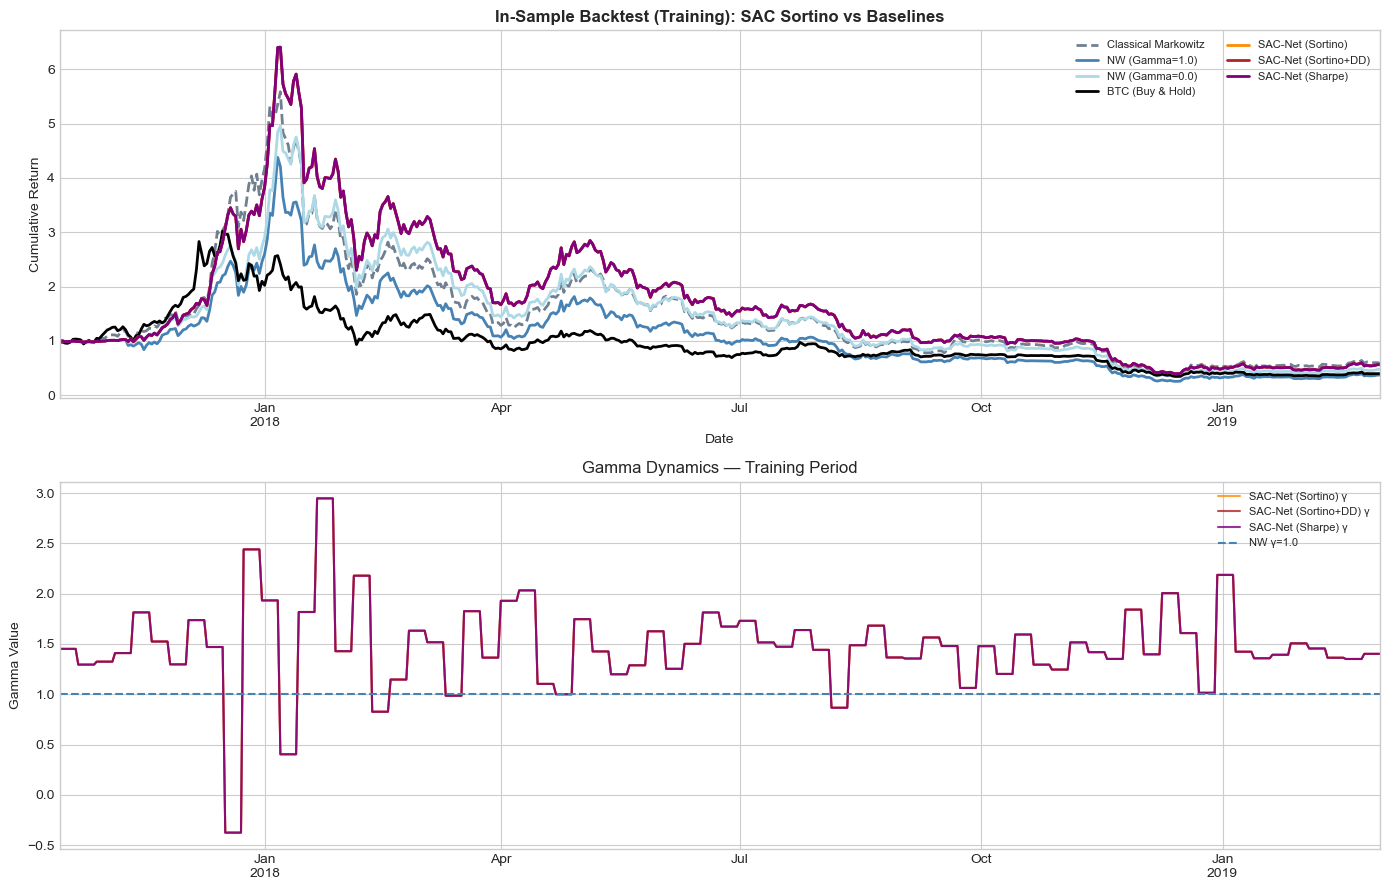

Saved: backtest_results/training_cumret_sortino.png


In [13]:
# ── Plot: Cumulative Returns (Training) ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
for name, r in results_train.items():
    (1 + r).cumprod().plot(
        ax=ax, label=name,
        color=COLORS.get(name, 'gray'),
        linewidth=2.0,
        linestyle='--' if 'Classical' in name else '-'
    )
ax.set_title('In-Sample Backtest (Training): SAC Sortino vs Baselines', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=8, ncol=2)

# Gamma dynamics
ax2 = axes[1]
for label, g in sac_gamma_train.items():
    g.plot(ax=ax2, label=f'{label} γ', color=COLORS.get(label, 'gray'), alpha=0.8)
ax2.axhline(1.0, color='steelblue', linestyle='--', label='NW γ=1.0')
ax2.set_ylabel('Gamma Value')
ax2.set_title('Gamma Dynamics — Training Period')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('backtest_results/training_cumret_sortino.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results/training_cumret_sortino.png')

In [14]:
# ── Metrics Table (Training) ──────────────────────────────────────────
stats_train = pd.DataFrame(
    {name: calculate_metrics(r) for name, r in results_train.items()}
).T
stats_train.index.name = 'Strategy'

# Std Sortino antar seeds
sortino_std_train = {}
for mode, label in reward_modes.items():
    sr = sac_seed_results_train[(mode, label)]
    sortino_per_seed = [calculate_metrics(r)['Sortino Ratio'] for r, _ in sr.values()]
    sortino_std_train[label] = np.std(sortino_per_seed)

stats_train['Sortino Std (seeds)'] = pd.Series(sortino_std_train)
stats_train.to_csv('backtest_results/metrics_training_sortino.csv')

print('=== In-Sample Metrics (Training) ===')
display_cols = ['Total Return', 'Ann. Return', 'Ann. Volatility',
                'Downside Std', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown']
print(stats_train[display_cols].round(4).to_string())

=== In-Sample Metrics (Training) ===
                      Total Return  Ann. Return  Ann. Volatility  Downside Std  Sharpe Ratio  Sortino Ratio  Max Drawdown
Strategy                                                                                                                 
Classical Markowitz        -0.4094      -0.2315           0.8418        0.6148       -0.2750        -0.2670       -0.9367
NW (Gamma=1.0)             -0.6291      -0.3910           0.8103        0.6065       -0.4825        -0.4635       -0.9419
NW (Gamma=0.0)             -0.5232      -0.3095           0.7853        0.5961       -0.3941        -0.3782       -0.9310
BTC (Buy & Hold)           -0.6028      -0.3698           0.7128        0.5332       -0.5188        -0.4904       -0.8855
SAC-Net (Sortino)          -0.4374      -0.2499           0.8087        0.6099       -0.3091        -0.2994       -0.9383
SAC-Net (Sortino+DD)       -0.4374      -0.2499           0.8087        0.6099       -0.3091        -0.2994  

## Phase 7: Out-of-Sample Backtest (Testing Data)

In [15]:
# Precompute test data
obs_cache_test, opt_cache_test, baseline_ret_cache_test = precompute_env_data(
    ret_test, window_size=SET_WINDOW
)

Precomputing 199 window positions...
Precomputation done! (199 positions cached)


In [16]:
# ── Baseline OOS ─────────────────────────────────────────────────────────
results_test = {}
for s in baseline_strategies:
    if isinstance(s, NetworkMarkowitz):
        s2 = NetworkMarkowitz(s.name, gamma=s.gamma)
    else:
        s2 = ClassicalMarkowitz(s.name)
    ret, _, _ = run_backtest_with_frequency(
        s2, ret_test, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_test[s.name] = ret
    print(f'  ✓ {s.name}')

if 'BTC' in ret_test.columns:
    results_test['BTC (Buy & Hold)'] = ret_test['BTC'].iloc[SET_WINDOW:]

# ── SAC OOS (multi-seed) ──────────────────────────────────────────────────
sac_seed_results_test = {}
sac_gamma_test        = {}

for mode, label in reward_modes.items():
    print(f'\nBacktest [{label}] — Testing...')
    sr = run_multiseed_backtest(mode, label, ret_test)
    sac_seed_results_test[(mode, label)] = sr
    mean_ret, _ = aggregate_seed_results(sr)
    mean_ret.name         = label
    results_test[label]   = mean_ret
    sac_gamma_test[label] = sr[SEEDS[0]][1]

print('\n✓ Out-of-sample backtest complete.')

  ✓ Classical Markowitz
  ✓ NW (Gamma=1.0)
  ✓ NW (Gamma=0.0)

Backtest [SAC-Net (Sortino)] — Testing...

Backtest [SAC-Net (Sortino+DD)] — Testing...

Backtest [SAC-Net (Sharpe)] — Testing...

✓ Out-of-sample backtest complete.


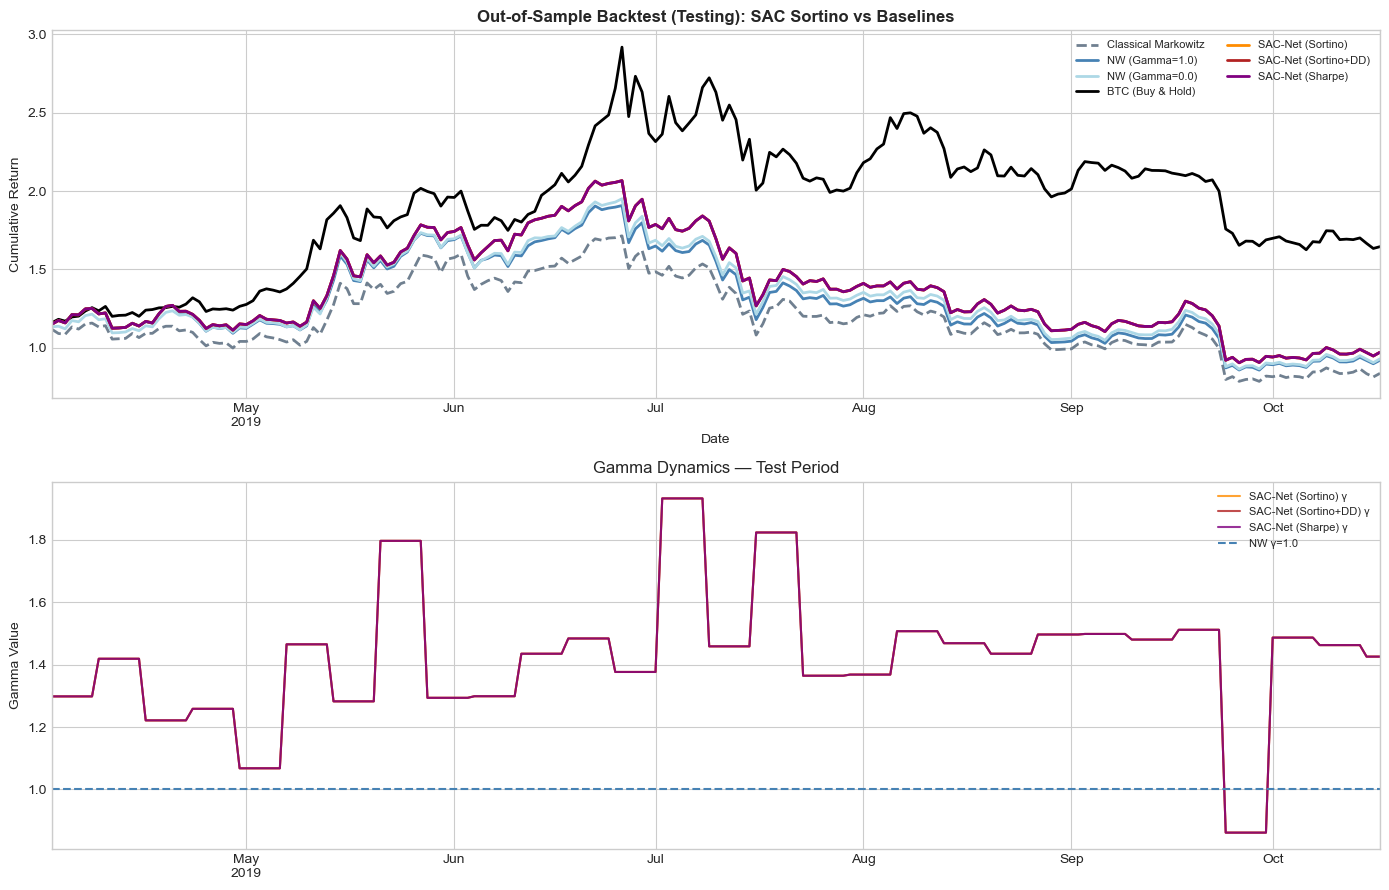

Saved: backtest_results/testing_cumret_sortino.png


In [17]:
# ── Plot: Cumulative Returns (Testing) ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
for name, r in results_test.items():
    (1 + r).cumprod().plot(
        ax=ax, label=name,
        color=COLORS.get(name, 'gray'),
        linewidth=2.0,
        linestyle='--' if 'Classical' in name else '-'
    )
ax.set_title('Out-of-Sample Backtest (Testing): SAC Sortino vs Baselines', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=8, ncol=2)

ax2 = axes[1]
for label, g in sac_gamma_test.items():
    g.plot(ax=ax2, label=f'{label} γ', color=COLORS.get(label, 'gray'), alpha=0.8)
ax2.axhline(1.0, color='steelblue', linestyle='--', label='NW γ=1.0')
ax2.set_ylabel('Gamma Value')
ax2.set_title('Gamma Dynamics — Test Period')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('backtest_results/testing_cumret_sortino.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results/testing_cumret_sortino.png')

In [18]:
# ── Metrics Table (Testing) ──────────────────────────────────────────
stats_test = pd.DataFrame(
    {name: calculate_metrics(r) for name, r in results_test.items()}
).T
stats_test.index.name = 'Strategy'

sortino_std_test = {}
for mode, label in reward_modes.items():
    sr = sac_seed_results_test[(mode, label)]
    sortino_per_seed = [calculate_metrics(r)['Sortino Ratio'] for r, _ in sr.values()]
    sortino_std_test[label] = np.std(sortino_per_seed)

stats_test['Sortino Std (seeds)'] = pd.Series(sortino_std_test)
stats_test.to_csv('backtest_results/metrics_testing_sortino.csv')

print('=== Out-of-Sample Metrics (Testing) ===')
print(stats_test[display_cols].round(4).to_string())

=== Out-of-Sample Metrics (Testing) ===
                      Total Return  Ann. Return  Ann. Volatility  Downside Std  Sharpe Ratio  Sortino Ratio  Max Drawdown
Strategy                                                                                                                 
Classical Markowitz        -0.1628      -0.2015           0.6305        0.5057       -0.3196        -0.2898       -0.5414
NW (Gamma=1.0)             -0.0791      -0.0991           0.6211        0.4827       -0.1596        -0.1513       -0.5502
NW (Gamma=0.0)             -0.0702      -0.0880           0.6201        0.4960       -0.1419        -0.1308       -0.5571
BTC (Buy & Hold)            0.6451       0.8783           0.6534        0.4761        1.3443         1.3750       -0.4428
SAC-Net (Sortino)          -0.0283      -0.0356           0.6336        0.5051       -0.0563        -0.0522       -0.5621
SAC-Net (Sortino+DD)       -0.0283      -0.0356           0.6336        0.5051       -0.0563        -0.052

## Phase Final: Perbandingan Sortino Ratio — Training vs Testing

Bagian ini membandingkan **Sortino Ratio** semua strategi di kedua periode secara komprehensif:
1. Tabel ringkasan Training vs Testing
2. Bar chart perbandingan
3. Analisis gap (overfitting check)
4. Per-seed Sortino untuk SAC

In [19]:
# ================================================================
# PHASE FINAL: SORTINO RATIO COMPARISON — ALL STRATEGIES
# ================================================================

all_strategies = list(results_train.keys())

# Kumpulkan Sortino Ratio untuk semua strategi
sortino_train = {name: calculate_metrics(r)['Sortino Ratio']
                 for name, r in results_train.items()}
sortino_test  = {name: calculate_metrics(r)['Sortino Ratio']
                 for name, r in results_test.items()}

# Tabel ringkasan
sortino_df = pd.DataFrame({
    'Sortino (Training)': sortino_train,
    'Sortino (Testing)' : sortino_test,
})
sortino_df['Gap (Train-Test)'] = sortino_df['Sortino (Training)'] - sortino_df['Sortino (Testing)']
sortino_df['Gap %']            = (sortino_df['Gap (Train-Test)'] / 
                                   sortino_df['Sortino (Training)'].abs() * 100).round(1)

# Tambah std antar seed untuk SAC
for mode, label in reward_modes.items():
    sr_tr  = sac_seed_results_train[(mode, label)]
    sr_te  = sac_seed_results_test[(mode, label)]
    s_tr   = [calculate_metrics(r)['Sortino Ratio'] for r, _ in sr_tr.values()]
    s_te   = [calculate_metrics(r)['Sortino Ratio'] for r, _ in sr_te.values()]
    sortino_df.loc[label, 'Sortino Std Train'] = np.std(s_tr)
    sortino_df.loc[label, 'Sortino Std Test']  = np.std(s_te)

sortino_df = sortino_df.round(4)
sortino_df.to_csv('backtest_results/sortino_comparison_all.csv')

print('=== SORTINO RATIO — SEMUA STRATEGI (Training vs Testing) ===')
print(sortino_df.to_string())

=== SORTINO RATIO — SEMUA STRATEGI (Training vs Testing) ===
                      Sortino (Training)  Sortino (Testing)  Gap (Train-Test)  Gap %  Sortino Std Train  Sortino Std Test
Classical Markowitz              -0.2670            -0.2898            0.0228    8.6                NaN               NaN
NW (Gamma=1.0)                   -0.4635            -0.1513           -0.3122  -67.4                NaN               NaN
NW (Gamma=0.0)                   -0.3782            -0.1308           -0.2475  -65.4                NaN               NaN
BTC (Buy & Hold)                 -0.4904             1.3750           -1.8654 -380.4                NaN               NaN
SAC-Net (Sortino)                -0.2994            -0.0522           -0.2473  -82.6             0.0685            0.0689
SAC-Net (Sortino+DD)             -0.2994            -0.0522           -0.2473  -82.6             0.0685            0.0689
SAC-Net (Sharpe)                 -0.2994            -0.0522           -0.2473  -82.6 

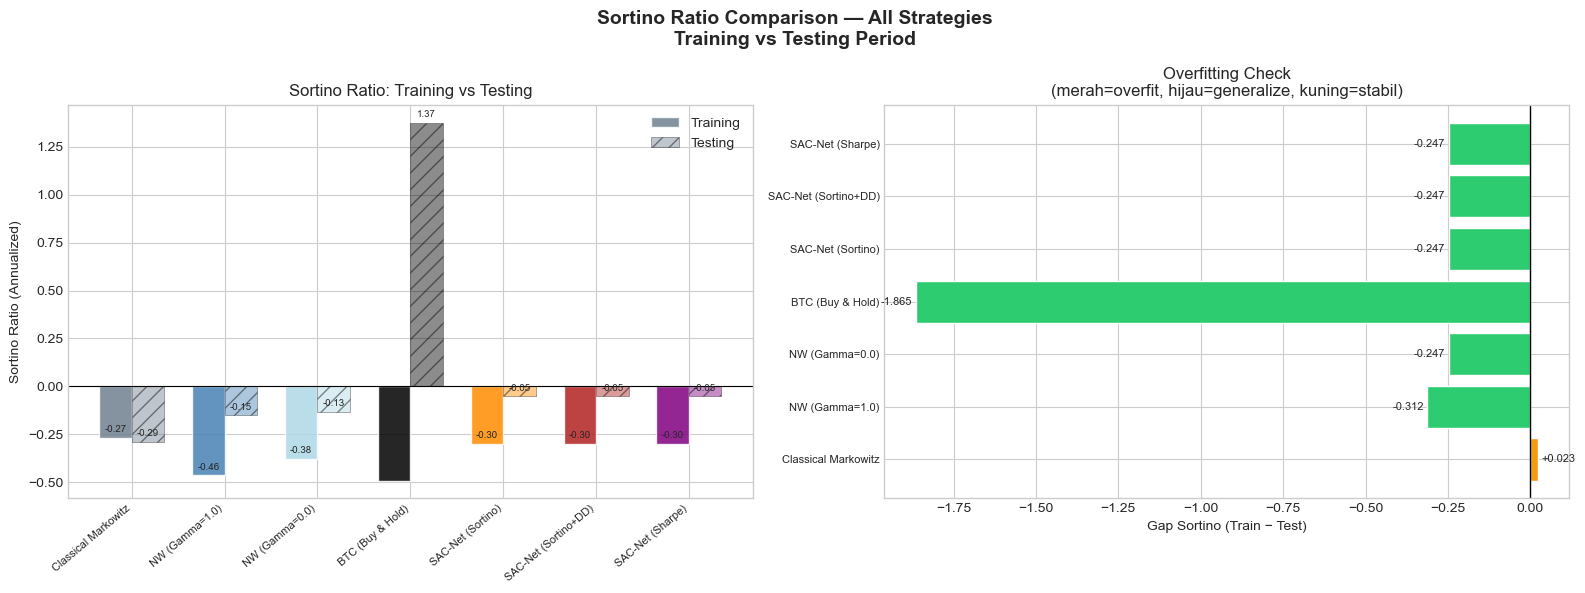

Saved: backtest_results/sortino_comparison_bar.png


In [20]:
# ================================================================
# VISUALISASI 1: Bar Chart Sortino — Training vs Testing
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sortino Ratio Comparison — All Strategies\nTraining vs Testing Period',
             fontsize=14, fontweight='bold')

strategy_names = list(sortino_train.keys())
bar_colors     = [COLORS.get(n, 'gray') for n in strategy_names]
x              = np.arange(len(strategy_names))
width          = 0.35

# --- Panel kiri: Grouped bar (Train vs Test) ---
ax = axes[0]
bars1 = ax.bar(x - width/2,
               [sortino_train[n] for n in strategy_names],
               width, label='Training',
               color=bar_colors, alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2,
               [sortino_test.get(n, 0) for n in strategy_names],
               width, label='Testing',
               color=bar_colors, alpha=0.45, edgecolor='black', linewidth=0.5, hatch='//')

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xticks(x)
ax.set_xticklabels(strategy_names, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Sortino Ratio (Annualized)')
ax.set_title('Sortino Ratio: Training vs Testing')
ax.legend()

# Tambahkan nilai di atas bar
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
            f'{h:.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
            f'{h:.2f}', ha='center', va='bottom', fontsize=7)

# --- Panel kanan: Gap (overfitting indicator) ---
ax2       = axes[1]
gaps      = [sortino_df.loc[n, 'Gap (Train-Test)'] if n in sortino_df.index else 0
             for n in strategy_names]
gap_colors = ['#e74c3c' if g > 0.5 else '#2ecc71' if g < 0 else '#f39c12' for g in gaps]
bars3     = ax2.barh(strategy_names, gaps, color=gap_colors, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1)
ax2.set_xlabel('Gap Sortino (Train − Test)')
ax2.set_title('Overfitting Check\n(merah=overfit, hijau=generalize, kuning=stabil)')
ax2.tick_params(axis='y', labelsize=8)

for bar, g in zip(bars3, gaps):
    ax2.text(g + (0.01 if g >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
             f'{g:+.3f}', va='center', ha='left' if g >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('backtest_results/sortino_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results/sortino_comparison_bar.png')

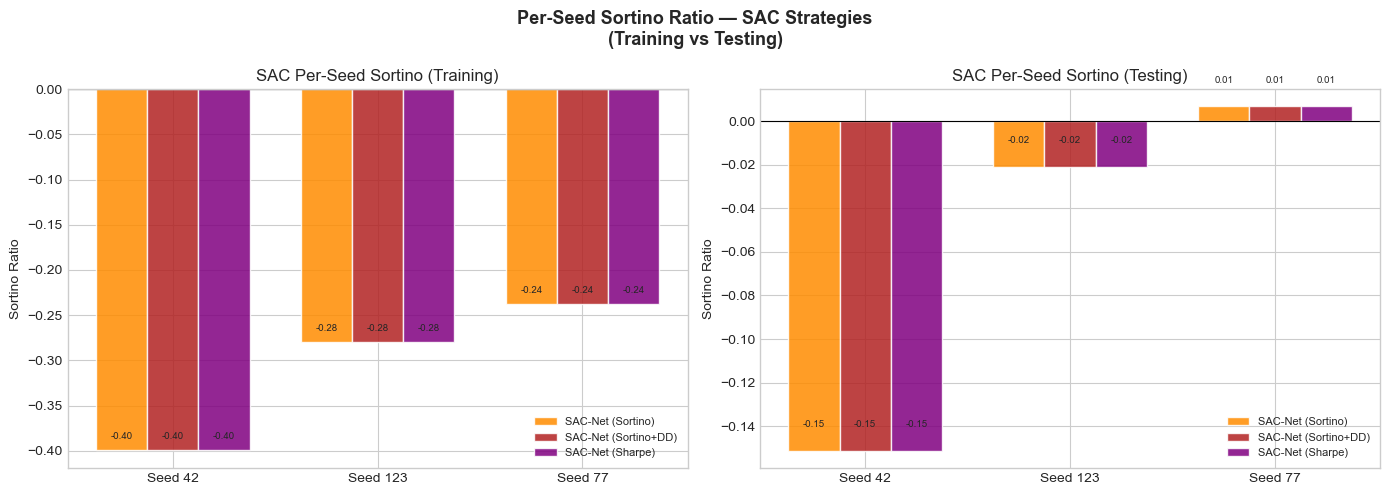

Saved: backtest_results/sortino_perseed.png


In [21]:
# ================================================================
# VISUALISASI 2: Per-Seed Sortino (SAC only)
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Seed Sortino Ratio — SAC Strategies\n(Training vs Testing)',
             fontsize=13, fontweight='bold')

seed_labels = [f'Seed {s}' for s in SEEDS]
mode_list   = list(reward_modes.items())
x_pos       = np.arange(len(SEEDS))
bar_w       = 0.25

for ax_idx, (data_period, period_name, seed_results_dict) in enumerate([
    ('train', 'Training', sac_seed_results_train),
    ('test',  'Testing',  sac_seed_results_test),
]):
    ax = axes[ax_idx]
    for i, (mode, label) in enumerate(mode_list):
        sr     = seed_results_dict[(mode, label)]
        s_vals = [calculate_metrics(sr[seed][0])['Sortino Ratio'] for seed in SEEDS]
        offset = (i - len(mode_list)/2 + 0.5) * bar_w
        bars   = ax.bar(x_pos + offset, s_vals, bar_w,
                        label=label, color=COLORS.get(label, 'gray'),
                        edgecolor='white', alpha=0.85)
        for bar, v in zip(bars, s_vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(seed_labels)
    ax.set_ylabel('Sortino Ratio')
    ax.set_title(f'SAC Per-Seed Sortino ({period_name})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('backtest_results/sortino_perseed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results/sortino_perseed.png')

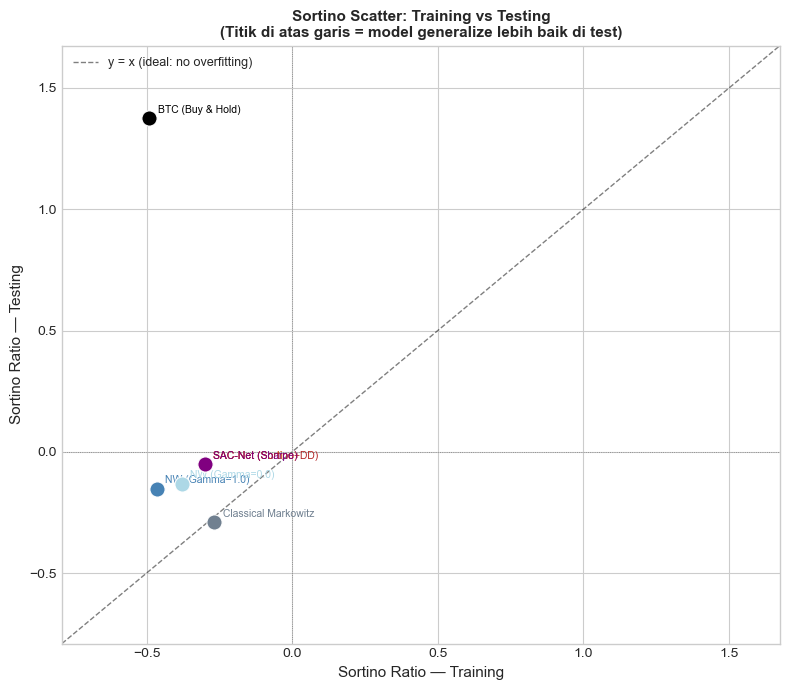

Saved: backtest_results/sortino_scatter_train_test.png


In [22]:
# ================================================================
# VISUALISASI 3: Scatter Sortino Training vs Testing
# (Ideal = dekat garis diagonal y=x)
# ================================================================

fig, ax = plt.subplots(figsize=(8, 7))

for name in strategy_names:
    s_tr = sortino_train.get(name, np.nan)
    s_te = sortino_test.get(name, np.nan)
    if np.isfinite(s_tr) and np.isfinite(s_te):
        color = COLORS.get(name, 'gray')
        ax.scatter(s_tr, s_te, s=120, color=color, zorder=5, edgecolor='white', linewidth=0.8)
        ax.annotate(name, (s_tr, s_te), textcoords='offset points',
                    xytext=(6, 4), fontsize=7.5, color=color)

# Garis diagonal y=x (ideal: train = test)
all_vals = list(sortino_train.values()) + list(sortino_test.values())
lim_min  = min(all_vals) - 0.3
lim_max  = max([v for v in all_vals if np.isfinite(v)]) + 0.3
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1,
        label='y = x (ideal: no overfitting)', alpha=0.5)
ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.6, linestyle=':')

ax.set_xlabel('Sortino Ratio — Training', fontsize=11)
ax.set_ylabel('Sortino Ratio — Testing', fontsize=11)
ax.set_title('Sortino Scatter: Training vs Testing\n'
             '(Titik di atas garis = model generalize lebih baik di test)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)

plt.tight_layout()
plt.savefig('backtest_results/sortino_scatter_train_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results/sortino_scatter_train_test.png')

In [23]:
# ================================================================
# TABEL FINAL: Ringkasan Lengkap Semua Metrik
# ================================================================

print('\n' + '='*70)
print('FINAL SUMMARY: SORTINO RATIO — TRAINING vs TESTING')
print('='*70)

summary = sortino_df[['Sortino (Training)', 'Sortino (Testing)', 'Gap (Train-Test)', 'Gap %']].copy()

# Ranking berdasarkan Sortino Testing
summary_sorted = summary.sort_values('Sortino (Testing)', ascending=False)
summary_sorted.index.name = 'Strategy'
print(summary_sorted.round(4).to_string())

# Interpretasi
best_test   = summary_sorted.index[0]
best_train  = summary.sort_values('Sortino (Training)', ascending=False).index[0]
min_gap     = summary_sorted['Gap (Train-Test)'].abs().idxmin()

print('\n' + '-'*70)
print('INTERPRETASI HASIL:')
print(f'  🥇 Best Sortino (Testing)  : {best_test}')
print(f'  🥇 Best Sortino (Training) : {best_train}')
print(f'  📊 Paling konsisten (min gap) : {min_gap}')
print()
print('Gap Interpretation:')
print('  Gap < 0.5  → generalisasi baik')
print('  Gap > 0.5  → potensi overfitting')
print('  Gap < 0    → model lebih baik di test (underfitting atau data test lebih mudah)')
print('-'*70)

# Print Sortino per seed untuk SAC
print('\nSortino Per-Seed (SAC — Mean ± Std):')
for mode, label in reward_modes.items():
    s_tr = [calculate_metrics(sac_seed_results_train[(mode, label)][seed][0])['Sortino Ratio']
            for seed in SEEDS]
    s_te = [calculate_metrics(sac_seed_results_test[(mode, label)][seed][0])['Sortino Ratio']
            for seed in SEEDS]
    print(f'  {label}:')
    print(f'    Training : {np.mean(s_tr):.4f} ± {np.std(s_tr):.4f}  (per seed: {[round(v,4) for v in s_tr]})')
    print(f'    Testing  : {np.mean(s_te):.4f} ± {np.std(s_te):.4f}  (per seed: {[round(v,4) for v in s_te]})')

print('='*70)
print('CSV saved: backtest_results/sortino_comparison_all.csv')


FINAL SUMMARY: SORTINO RATIO — TRAINING vs TESTING
                      Sortino (Training)  Sortino (Testing)  Gap (Train-Test)  Gap %
Strategy                                                                            
BTC (Buy & Hold)                 -0.4904             1.3750           -1.8654 -380.4
SAC-Net (Sortino)                -0.2994            -0.0522           -0.2473  -82.6
SAC-Net (Sortino+DD)             -0.2994            -0.0522           -0.2473  -82.6
SAC-Net (Sharpe)                 -0.2994            -0.0522           -0.2473  -82.6
NW (Gamma=0.0)                   -0.3782            -0.1308           -0.2475  -65.4
NW (Gamma=1.0)                   -0.4635            -0.1513           -0.3122  -67.4
Classical Markowitz              -0.2670            -0.2898            0.0228    8.6

----------------------------------------------------------------------
INTERPRETASI HASIL:
  🥇 Best Sortino (Testing)  : BTC (Buy & Hold)
  🥇 Best Sortino (Training) : Classical Mark

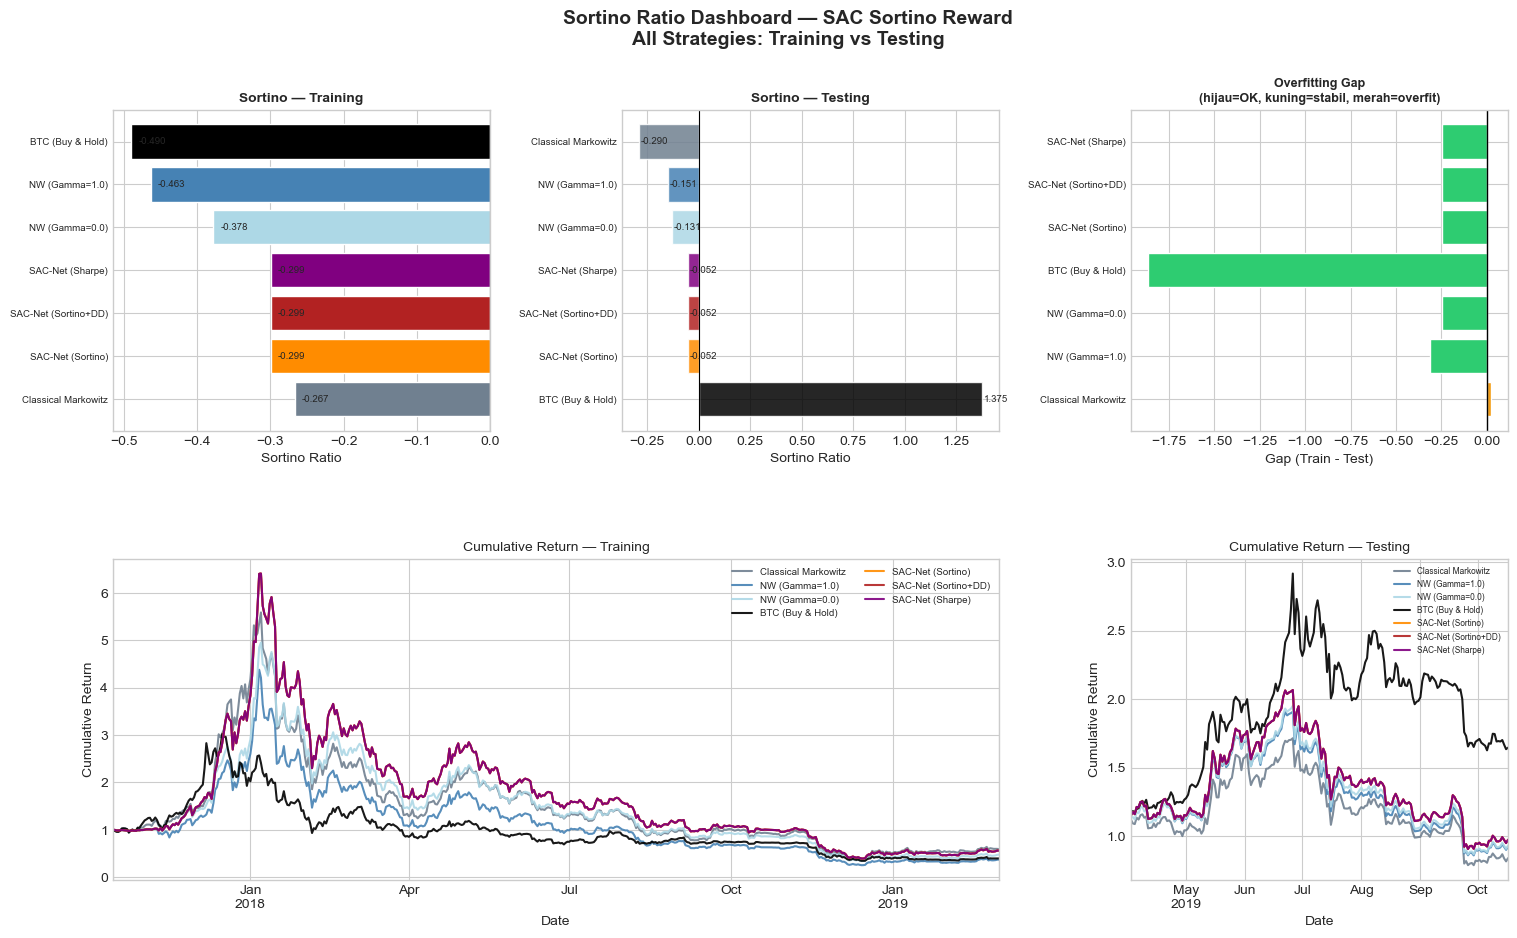


✅ Phase Final complete!
Outputs saved to backtest_results/:
  - sortino_comparison_all.csv
  - sortino_comparison_bar.png
  - sortino_perseed.png
  - sortino_scatter_train_test.png
  - sortino_final_dashboard.png
  - metrics_training_sortino.csv
  - metrics_testing_sortino.csv


In [24]:
# ================================================================
# VISUALISASI 4: Dashboard Final Sortino
# ================================================================

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Sortino Ratio Dashboard — SAC Sortino Reward\nAll Strategies: Training vs Testing',
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# --- Panel 1: Bar chart Sortino (Training) ---
ax1 = fig.add_subplot(gs[0, 0])
sorted_by_train = sorted(sortino_train.items(), key=lambda x: x[1], reverse=True)
names_tr, vals_tr = zip(*sorted_by_train)
bars = ax1.barh(names_tr, vals_tr, color=[COLORS.get(n, 'gray') for n in names_tr], edgecolor='white')
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlabel('Sortino Ratio')
ax1.set_title('Sortino — Training', fontsize=10, fontweight='bold')
ax1.tick_params(axis='y', labelsize=7)
for bar, v in zip(bars, vals_tr):
    ax1.text(v + 0.01, bar.get_y() + bar.get_height()/2, f'{v:.3f}',
             va='center', fontsize=7)

# --- Panel 2: Bar chart Sortino (Testing) ---
ax2 = fig.add_subplot(gs[0, 1])
sorted_by_test = sorted(sortino_test.items(), key=lambda x: x[1], reverse=True)
names_te, vals_te = zip(*sorted_by_test)
bars2 = ax2.barh(names_te, vals_te, color=[COLORS.get(n, 'gray') for n in names_te],
                 edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Sortino Ratio')
ax2.set_title('Sortino — Testing', fontsize=10, fontweight='bold')
ax2.tick_params(axis='y', labelsize=7)
for bar, v in zip(bars2, vals_te):
    ax2.text(v + 0.01, bar.get_y() + bar.get_height()/2, f'{v:.3f}',
             va='center', fontsize=7)

# --- Panel 3: Gap chart ---
ax3   = fig.add_subplot(gs[0, 2])
gap_names = list(sortino_df.index)
gap_vals  = sortino_df['Gap (Train-Test)'].values
gc        = ['#e74c3c' if g > 0.5 else '#2ecc71' if g < 0 else '#f39c12' for g in gap_vals]
bars3     = ax3.barh(gap_names, gap_vals, color=gc, edgecolor='white')
ax3.axvline(0, color='black', linewidth=1)
ax3.set_xlabel('Gap (Train - Test)')
ax3.set_title('Overfitting Gap\n(hijau=OK, kuning=stabil, merah=overfit)',
              fontsize=9, fontweight='bold')
ax3.tick_params(axis='y', labelsize=7)

# --- Panel 4: Cumulative return Training (top performers) ---
ax4 = fig.add_subplot(gs[1, 0:2])
for name, r in results_train.items():
    (1 + r).cumprod().plot(ax=ax4, label=name, color=COLORS.get(name, 'gray'),
                           linewidth=1.5, alpha=0.9)
ax4.set_title('Cumulative Return — Training', fontsize=10)
ax4.set_ylabel('Cumulative Return')
ax4.legend(fontsize=7, ncol=2)

# --- Panel 5: Cumulative return Testing ---
ax5 = fig.add_subplot(gs[1, 2])
for name, r in results_test.items():
    (1 + r).cumprod().plot(ax=ax5, label=name, color=COLORS.get(name, 'gray'),
                           linewidth=1.5, alpha=0.9)
ax5.set_title('Cumulative Return — Testing', fontsize=10)
ax5.set_ylabel('Cumulative Return')
ax5.legend(fontsize=6)

plt.savefig('backtest_results/sortino_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Phase Final complete!')
print('Outputs saved to backtest_results/:')
print('  - sortino_comparison_all.csv')
print('  - sortino_comparison_bar.png')
print('  - sortino_perseed.png')
print('  - sortino_scatter_train_test.png')
print('  - sortino_final_dashboard.png')
print('  - metrics_training_sortino.csv')
print('  - metrics_testing_sortino.csv')